# 03 · TF-IDF + K-means 聚类

**分词**：沿用 `src/text_utils.py` 的 jieba 口径（02 已把结果存进 `tokens` 列，直接复用，
保证 02/03 完全同口径）。

**两份并列**：
| 数据集 | 定义 | n |
|---|---|---|
| **主结果** | 2023+ 且提及品类核心词 | 260 |
| 对照 | 2023+ 全量（含 50.3% 离题） | 523 |

对照组的作用是**噪声诊断**：如果离题评论会被 K-means 甩成独立簇，就能量化噪声的规模和形态。

### K 值选择规则（本次新增约束）

1. 肘部法（inertia）与轮廓系数各出一张图；
2. 每个 K 同时报告**最小簇规模**；
3. **任何簇 < 20 条的 K 一律不可用**，不进入候选；
4. 在可用候选里按轮廓系数最高选 K；
5. 选定后做**稳定性检查**：换 3 个 `random_state` 重跑，用 ARI / AMI 衡量划分一致性。
   若不一致就如实报告结构不稳，不挑好看的结果留下。

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             adjusted_rand_score, adjusted_mutual_info_score)
from sklearn.metrics.pairwise import cosine_distances
warnings.filterwarnings('ignore')

PROJ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJ / 'src'))
import text_utils as T

PROC = PROJ / 'data' / 'processed'
FIG  = PROJ / 'outputs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

font = T.get_cjk_font(verbose=True)          # 跨平台中文字体，含回退
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(PROC / 'comments_sentiment.csv', encoding='utf-8-sig',
                 parse_dates=['created_at'])
df['tokens'] = df['tokens'].fillna('')

DATASETS = {
    'primary': dict(name='主结果·2023+相关集', mask=df['is_primary']),
    'control': dict(name='对照·2023+全量',     mask=df['recent']),
}

MIN_CLUSTER = 20          # 硬约束：任何簇 < 20 条则该 K 不可用
K_RANGE     = range(2, 11)
SEEDS       = [0, 7, 2024]

print('读入 :', len(df), '条')
for k, v in DATASETS.items():
    print(f"  {k:8s} {v['name']:22s} n = {int(v['mask'].sum())}")

中文字体: SimHei
读入 : 881 条
  primary  主结果·2023+相关集           n = 260
  control  对照·2023+全量             n = 523


## 1. 各平台样本量（相关集 vs 全量）

后面所有平台对比图都会标注 n。

=== 各平台样本量 ===

主结果·2023+相关集  (总 n = 260)
        n    占比%
平台              
知乎  131.0   50.4
B站   92.0   35.4
抖音   37.0   14.2
合计  260.0  100.0

对照·2023+全量  (总 n = 523)
        n    占比%
平台              
知乎  219.0   41.9
B站  215.0   41.1
抖音   89.0   17.0
合计  523.0  100.0

=== 各平台相关率（筛掉离题后的存活比例）===
          2023+全量 n  相关集 n  相关率%
platform                        
知乎              219    131  59.8
B站              215     92  42.8
抖音               89     37  41.6


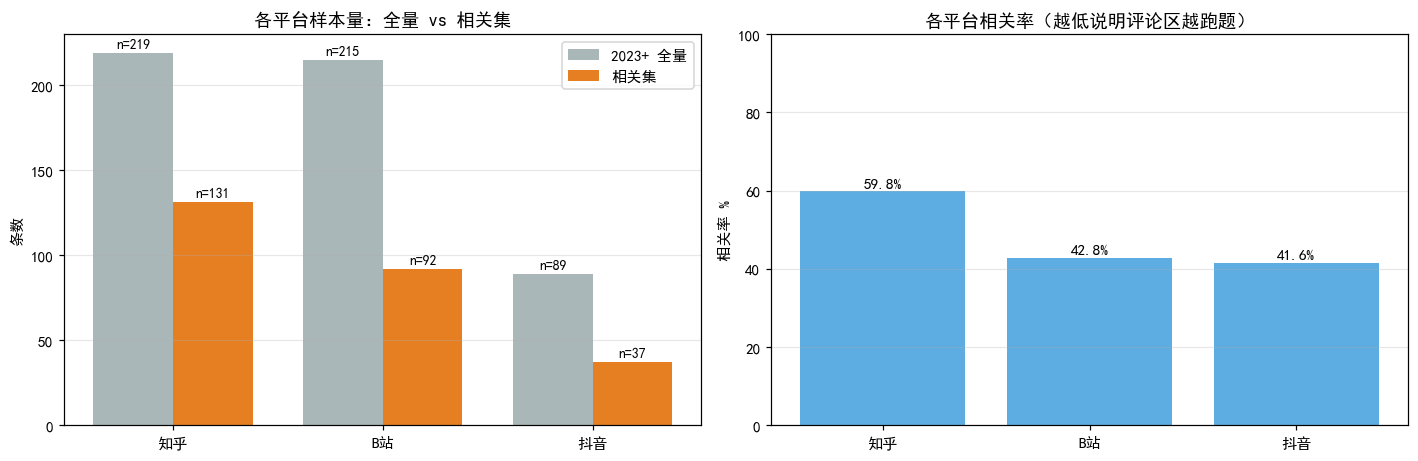

In [2]:
rows = []
for key, v in DATASETS.items():
    sub = df[v['mask']]
    for plat, n in sub['platform'].value_counts().items():
        rows.append({'数据集': v['name'], '平台': plat, 'n': int(n),
                     '占比%': round(n / len(sub) * 100, 1)})
plat_tbl = pd.DataFrame(rows)

print('=== 各平台样本量 ===')
for key, v in DATASETS.items():
    t = plat_tbl[plat_tbl['数据集'] == v['name']].set_index('平台')[['n', '占比%']]
    t.loc['合计'] = [t['n'].sum(), 100.0]
    print(f"\n{v['name']}  (总 n = {int(v['mask'].sum())})")
    print(t.to_string())

# 相关集中各平台的「存活率」：筛掉离题后还剩多少
rec = df[df['recent']]
surv = pd.DataFrame({
    '2023+全量 n': rec['platform'].value_counts(),
    '相关集 n':    rec[rec['on_topic']]['platform'].value_counts(),
})
surv['相关率%'] = (surv['相关集 n'] / surv['2023+全量 n'] * 100).round(1)
print('\n=== 各平台相关率（筛掉离题后的存活比例）===')
print(surv.to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
x, w = np.arange(len(surv)), 0.38
b1 = ax[0].bar(x - w/2, surv['2023+全量 n'], w, label='2023+ 全量', color='#AAB7B8')
b2 = ax[0].bar(x + w/2, surv['相关集 n'],    w, label='相关集', color='#E67E22')
for bars in (b1, b2):
    for b in bars:
        ax[0].text(b.get_x() + b.get_width()/2, b.get_height() + 3,
                   f'n={int(b.get_height())}', ha='center',
                   fontproperties=font, fontsize=9)
ax[0].set_xticks(x); ax[0].set_xticklabels(surv.index, fontproperties=font)
ax[0].set_ylabel('条数', fontproperties=font)
ax[0].set_title('各平台样本量：全量 vs 相关集', fontproperties=font, fontsize=12)
ax[0].legend(prop=font, fontsize=9); ax[0].grid(alpha=.3, axis='y')

bars = ax[1].bar(surv.index, surv['相关率%'], color='#5DADE2')
for b in bars:
    ax[1].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
               f"{b.get_height():.1f}%", ha='center', fontproperties=font, fontsize=10)
ax[1].set_ylabel('相关率 %', fontproperties=font)
ax[1].set_title('各平台相关率（越低说明评论区越跑题）', fontproperties=font, fontsize=12)
ax[1].set_xticks(range(len(surv))); ax[1].set_xticklabels(surv.index, fontproperties=font)
ax[1].set_ylim(0, 100); ax[1].grid(alpha=.3, axis='y')

plt.tight_layout()
plt.savefig(FIG / '03_platform_n.png', bbox_inches='tight')
plt.show()

## 2. 向量化 + K 值扫描

TF-IDF 用 02 已算好的 `tokens`（空格分隔），`tokenizer=str.split` 直接切，不再二次分词。

In [3]:
def vectorize(sub, min_df=3, max_df=0.6):
    vec = TfidfVectorizer(tokenizer=str.split, token_pattern=None,
                          lowercase=False, min_df=min_df, max_df=max_df)
    X = vec.fit_transform(sub['tokens'])
    return vec, X


def scan_k(X, k_range=K_RANGE, seed=42):
    out = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        sizes = np.bincount(km.labels_, minlength=k)
        sil = silhouette_score(X, km.labels_, metric='cosine')
        out.append({'K': k,
                    'inertia': round(km.inertia_, 2),
                    '轮廓系数': round(sil, 4),
                    '最小簇': int(sizes.min()),
                    '最大簇': int(sizes.max()),
                    '可用': '是' if sizes.min() >= MIN_CLUSTER else '否',
                    '_sizes': sizes.tolist()})
    return pd.DataFrame(out)


scans, vecs, mats = {}, {}, {}
for key, v in DATASETS.items():
    sub = df[v['mask']].reset_index(drop=True)
    vec, X = vectorize(sub)
    vecs[key], mats[key] = vec, X
    scans[key] = scan_k(X)
    print(f"=== {v['name']} ===")
    print('n =', X.shape[0], '| 词表大小 =', X.shape[1],
          '| 稀疏度 =', f'{X.nnz / (X.shape[0] * X.shape[1]) * 100:.2f}%')
    print(scans[key].drop(columns='_sizes').to_string(index=False))
    print()

=== 主结果·2023+相关集 ===
n = 260 | 词表大小 = 185 | 稀疏度 = 2.16%
 K  inertia   轮廓系数  最小簇  最大簇 可用
 2   228.47 0.0581   73  187  是
 3   221.51 0.0671   12  181  否
 4   214.98 0.0843   12  154  否
 5   210.86 0.0939   12  137  否
 6   207.55 0.0770   10  134  否
 7   202.77 0.1106   12  117  否
 8   198.71 0.1211   11  102  否
 9   196.08 0.1249    3   98  否
10   194.58 0.0997    3  108  否



=== 对照·2023+全量 ===
n = 523 | 词表大小 = 344 | 稀疏度 = 1.05%
 K  inertia   轮廓系数  最小簇  最大簇 可用
 2   451.15 0.0278   72  451  是
 3   444.66 0.0320   42  417  是
 4   443.55 0.0311    4  421  否
 5   434.34 0.0411   10  385  否
 6   430.51 0.0378   16  377  否
 7   428.83 0.0401    4  408  否
 8   422.22 0.0553    4  335  否
 9   416.92 0.0532   12  343  否
10   415.16 0.0576    4  368  否



## 3. 肘部法（图 1/2）

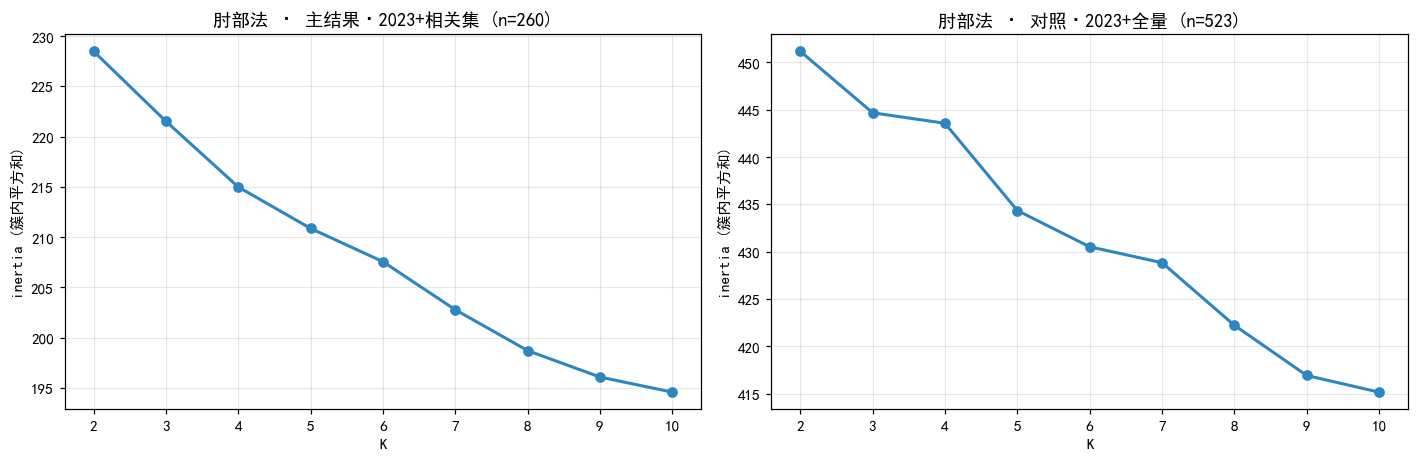

主结果·2023+相关集 inertia 逐步降幅 :
 K  inertia    降幅
 2   228.47   NaN
 3   221.51 -6.96
 4   214.98 -6.53
 5   210.86 -4.12
 6   207.55 -3.31
 7   202.77 -4.78
 8   198.71 -4.06
 9   196.08 -2.63
10   194.58 -1.50

对照·2023+全量 inertia 逐步降幅 :
 K  inertia    降幅
 2   451.15   NaN
 3   444.66 -6.49
 4   443.55 -1.11
 5   434.34 -9.21
 6   430.51 -3.83
 7   428.83 -1.68
 8   422.22 -6.61
 9   416.92 -5.30
10   415.16 -1.76



In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
for a, (key, v) in zip(ax, DATASETS.items()):
    s = scans[key]
    a.plot(s['K'], s['inertia'], marker='o', lw=2, color='#2E86C1')
    a.set_title(f"肘部法 · {v['name']} (n={mats[key].shape[0]})",
                fontproperties=font, fontsize=12)
    a.set_xlabel('K', fontproperties=font)
    a.set_ylabel('inertia (簇内平方和)', fontproperties=font)
    a.set_xticks(list(K_RANGE))
    a.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIG / '03_elbow.png', bbox_inches='tight')
plt.show()

for key, v in DATASETS.items():
    s = scans[key]
    d1 = s['inertia'].diff()
    print(f"{v['name']} inertia 逐步降幅 :")
    print(pd.DataFrame({'K': s['K'], 'inertia': s['inertia'], '降幅': d1.round(2)})
          .to_string(index=False))
    print()

## 4. 轮廓系数 + 最小簇规模（图 2/2）

灰色阴影 = 最小簇 < 20 的不可用区；只有落在可用区的 K 才进入候选。

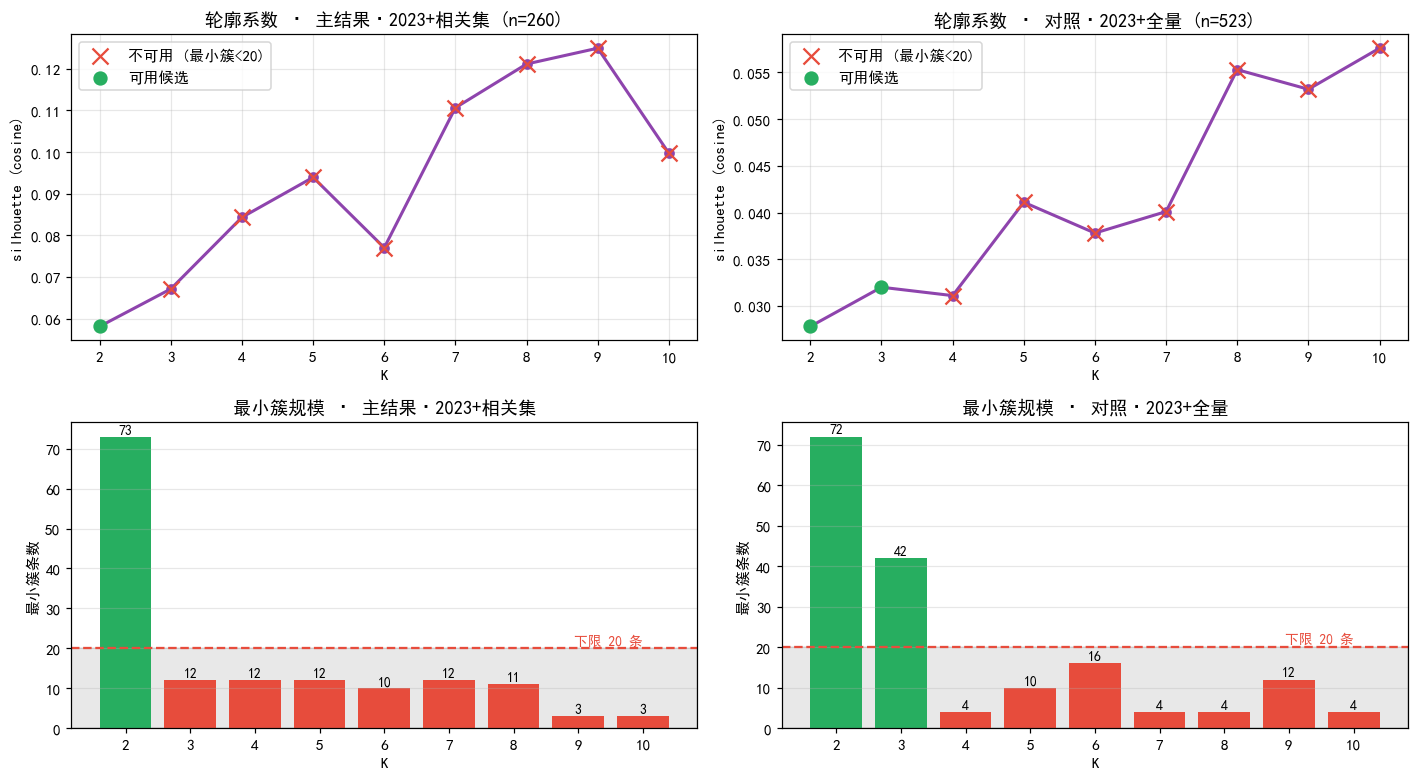

=== 主结果·2023+相关集 ===
  可用候选 K : [2]
  排除的 K   : [3, 4, 5, 6, 7, 8, 9, 10] （最小簇分别为 [12, 12, 12, 10, 12, 11, 3, 3] ）
  选定 K = 2（候选中轮廓系数最高 = 0.0581，最小簇 73 条）

=== 对照·2023+全量 ===
  可用候选 K : [2, 3]
  排除的 K   : [4, 5, 6, 7, 8, 9, 10] （最小簇分别为 [4, 10, 16, 4, 4, 12, 4] ）
  选定 K = 3（候选中轮廓系数最高 = 0.032，最小簇 42 条）



In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.2))
for j, (key, v) in enumerate(DATASETS.items()):
    s = scans[key]
    a = axes[0, j]
    ok = s['可用'] == '是'
    a.plot(s['K'], s['轮廓系数'], marker='o', lw=2, color='#8E44AD', zorder=3)
    a.scatter(s.loc[~ok, 'K'], s.loc[~ok, '轮廓系数'], marker='x', s=110,
              color='#E74C3C', zorder=4, label='不可用 (最小簇<20)')
    a.scatter(s.loc[ok, 'K'], s.loc[ok, '轮廓系数'], s=70,
              color='#27AE60', zorder=4, label='可用候选')
    a.set_title(f"轮廓系数 · {v['name']} (n={mats[key].shape[0]})",
                fontproperties=font, fontsize=12)
    a.set_xlabel('K', fontproperties=font)
    a.set_ylabel('silhouette (cosine)', fontproperties=font)
    a.set_xticks(list(K_RANGE)); a.grid(alpha=.3)
    a.legend(prop=font, fontsize=8)

    a2 = axes[1, j]
    bars = a2.bar(s['K'], s['最小簇'],
                  color=['#27AE60' if o else '#E74C3C' for o in ok])
    a2.axhline(MIN_CLUSTER, color='#E74C3C', ls='--', lw=1.5)
    a2.axhspan(0, MIN_CLUSTER, color='grey', alpha=.18, zorder=0)
    a2.text(K_RANGE[-1], MIN_CLUSTER + 1, f'下限 {MIN_CLUSTER} 条',
            ha='right', fontproperties=font, color='#E74C3C', fontsize=9)
    for b in bars:
        a2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
                str(int(b.get_height())), ha='center',
                fontproperties=font, fontsize=9)
    a2.set_title(f"最小簇规模 · {v['name']}", fontproperties=font, fontsize=12)
    a2.set_xlabel('K', fontproperties=font)
    a2.set_ylabel('最小簇条数', fontproperties=font)
    a2.set_xticks(list(K_RANGE)); a2.grid(alpha=.3, axis='y')

plt.tight_layout()
plt.savefig(FIG / '03_silhouette_minsize.png', bbox_inches='tight')
plt.show()

CHOSEN = {}
for key, v in DATASETS.items():
    s = scans[key]
    cand = s[s['可用'] == '是']
    print(f"=== {v['name']} ===")
    if cand.empty:
        CHOSEN[key] = None
        print('  没有任何 K 满足最小簇 >= 20 —— 该数据集不做聚类结论')
    else:
        best = cand.loc[cand['轮廓系数'].idxmax()]
        CHOSEN[key] = int(best['K'])
        print('  可用候选 K :', cand['K'].tolist())
        print('  排除的 K   :', s.loc[s['可用'] == '否', 'K'].tolist(),
              '（最小簇分别为', s.loc[s['可用'] == '否', '最小簇'].tolist(), '）')
        print(f"  选定 K = {CHOSEN[key]}（候选中轮廓系数最高 = {best['轮廓系数']}，"
              f"最小簇 {int(best['最小簇'])} 条）")
    print()

## 5. 稳定性检查

换 3 个 `random_state` 重跑选定的 K，两两比较划分一致性。

- **ARI / AMI**：1.0 = 完全一致，0 ≈ 随机。经验上 ARI > 0.75 算稳，< 0.5 说明结构不稳。
- 注意 `n_init=10` 本身会削弱随机性，所以这是**偏乐观**的稳定性估计；额外再用
  `n_init=1` 跑一遍，看最坏情况。

In [6]:
stab_summary = {}
for key, v in DATASETS.items():
    k = CHOSEN[key]
    print('=' * 74)
    print(f"{v['name']} | K = {k}")
    if k is None:
        print('  跳过（无可用 K）'); continue
    X = mats[key]
    for n_init, tag in [(10, 'n_init=10（与主分析一致）'), (1, 'n_init=1（最坏情况）')]:
        labs = {sd: KMeans(n_clusters=k, n_init=n_init, random_state=sd).fit_predict(X)
                for sd in SEEDS}
        pairs = [(a, b) for i, a in enumerate(SEEDS) for b in SEEDS[i+1:]]
        recs = [{'对比': f'seed {a} vs {b}',
                 'ARI': round(adjusted_rand_score(labs[a], labs[b]), 4),
                 'AMI': round(adjusted_mutual_info_score(labs[a], labs[b]), 4)}
                for a, b in pairs]
        tb = pd.DataFrame(recs)
        print(f'\n  {tag}')
        print('   ', tb.to_string(index=False).replace('\n', '\n    '))
        print('    簇规模 :', {sd: sorted(np.bincount(l, minlength=k).tolist(), reverse=True)
                              for sd, l in labs.items()})
        mean_ari = tb['ARI'].mean()
        verdict = ('稳定' if mean_ari > 0.75 else
                   '中等' if mean_ari > 0.5 else '不稳定')
        print(f'    平均 ARI = {mean_ari:.4f}  ->  {verdict}')
        if n_init == 10:
            stab_summary[key] = {'K': k, 'mean_ARI': round(mean_ari, 4), '判定': verdict}
        else:
            stab_summary[key]['mean_ARI_ninit1'] = round(mean_ari, 4)
    print()

print('=== 稳定性汇总 ===')
print(pd.DataFrame(stab_summary).T.to_string())

主结果·2023+相关集 | K = 2

  n_init=10（与主分析一致）
                对比    ARI    AMI
       seed 0 vs 7 0.9523 0.9083
    seed 0 vs 2024 0.9681 0.9338
    seed 7 vs 2024 0.9839 0.9620
    簇规模 : {0: [187, 73], 7: [190, 70], 2024: [189, 71]}
    平均 ARI = 0.9681  ->  稳定

  n_init=1（最坏情况）
                对比     ARI    AMI
       seed 0 vs 7  0.2720 0.2639
    seed 0 vs 2024 -0.0725 0.0505
    seed 7 vs 2024 -0.0820 0.0263
    簇规模 : {0: [187, 73], 7: [238, 22], 2024: [231, 29]}
    平均 ARI = 0.0392  ->  不稳定

对照·2023+全量 | K = 3



  n_init=10（与主分析一致）
                对比    ARI    AMI
       seed 0 vs 7 0.6222 0.5821
    seed 0 vs 2024 0.4467 0.4925
    seed 7 vs 2024 0.6474 0.6214
    簇规模 : {0: [403, 65, 55], 7: [434, 71, 18], 2024: [420, 64, 39]}
    平均 ARI = 0.5721  ->  中等

  n_init=1（最坏情况）
                对比    ARI    AMI
       seed 0 vs 7 0.0152 0.0001
    seed 0 vs 2024 0.4385 0.4157
    seed 7 vs 2024 0.6337 0.5645
    簇规模 : {0: [464, 51, 8], 7: [447, 64, 12], 2024: [420, 64, 39]}
    平均 ARI = 0.3625  ->  不稳定

=== 稳定性汇总 ===
         K mean_ARI  判定 mean_ARI_ninit1
primary  2   0.9681  稳定          0.0392
control  3   0.5721  中等          0.3625


## 6. 正式聚类 + PCA 散点图

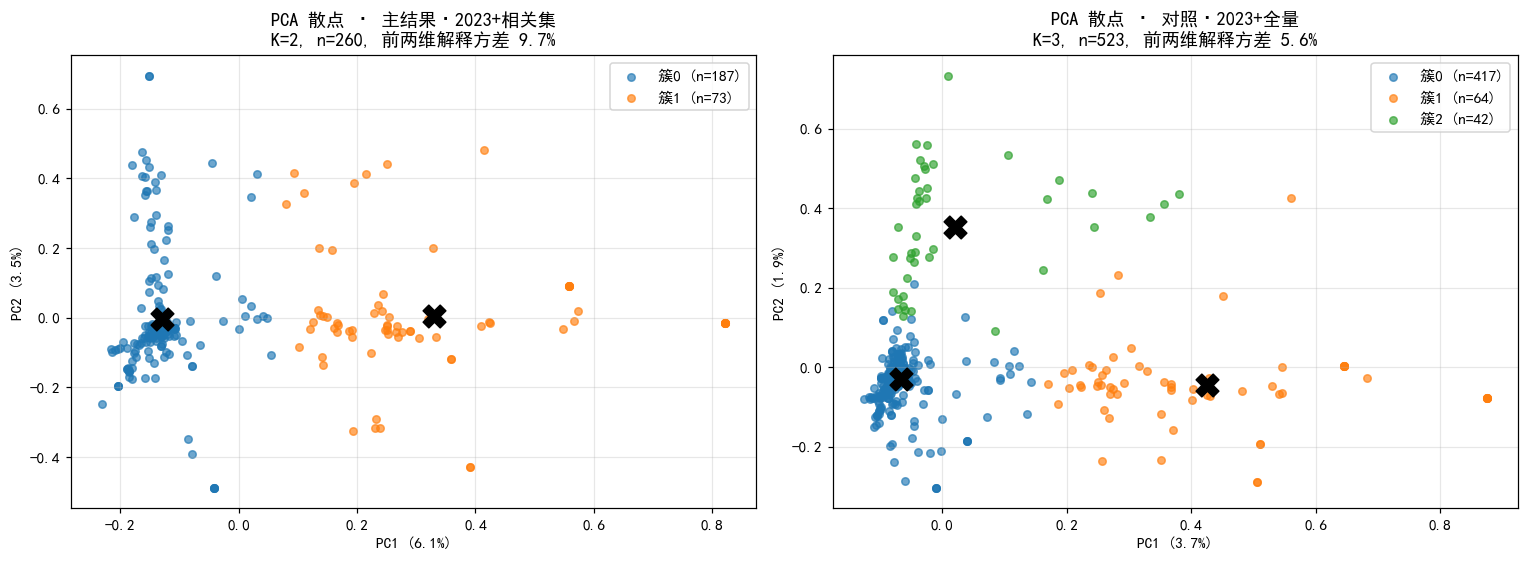

主结果·2023+相关集: 前两维仅解释 9.7% 方差 —— 散点图只是投影示意，簇的真实分离看轮廓系数
对照·2023+全量: 前两维仅解释 5.6% 方差 —— 散点图只是投影示意，簇的真实分离看轮廓系数


In [7]:
results = {}
for key, v in DATASETS.items():
    k = CHOSEN[key]
    if k is None:
        continue
    sub = df[v['mask']].reset_index(drop=True).copy()
    X = mats[key]
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    sub['cluster'] = km.labels_
    sub['sil'] = silhouette_samples(X, km.labels_, metric='cosine')
    results[key] = dict(sub=sub, km=km, X=X, vec=vecs[key], k=k)

fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5.2))
if len(results) == 1:
    axes = [axes]
for a, (key, r) in zip(axes, results.items()):
    Xd = r['X'].toarray()
    pca = PCA(n_components=2, random_state=42)
    xy = pca.fit_transform(Xd)
    cen = pca.transform(r['km'].cluster_centers_)
    sizes = np.bincount(r['sub']['cluster'], minlength=r['k'])
    cmap = plt.get_cmap('tab10')
    for c in range(r['k']):
        m = r['sub']['cluster'] == c
        a.scatter(xy[m, 0], xy[m, 1], s=24, alpha=.65, color=cmap(c),
                  label=f'簇{c} (n={sizes[c]})')
    a.scatter(cen[:, 0], cen[:, 1], marker='X', s=220, c='black', zorder=5)
    ev = pca.explained_variance_ratio_
    a.set_title(f"PCA 散点 · {DATASETS[key]['name']}\n"
                f"K={r['k']}, n={len(r['sub'])}, 前两维解释方差 {ev.sum()*100:.1f}%",
                fontproperties=font, fontsize=12)
    a.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontproperties=font)
    a.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontproperties=font)
    a.legend(prop=font, fontsize=8)
    a.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIG / '03_pca_scatter.png', bbox_inches='tight')
plt.show()

for key, r in results.items():
    ev = PCA(n_components=2, random_state=42).fit(r['X'].toarray()).explained_variance_ratio_
    print(f"{DATASETS[key]['name']}: 前两维仅解释 {ev.sum()*100:.1f}% 方差 "
          f"—— 散点图只是投影示意，簇的真实分离看轮廓系数")

## 7. 每簇 top 20 特征词 + 5 条代表评论

代表评论仅用于方法说明，已截断至 40 字并去除所有标识信息，不指向具体用户。

In [8]:
for key, r in results.items():
    sub, vec, km, X, k = r['sub'], r['vec'], r['km'], r['X'], r['k']
    terms = np.array(vec.get_feature_names_out())
    print('#' * 78)
    print(f"# {DATASETS[key]['name']}  |  K = {k}  |  n = {len(sub)}")
    print('#' * 78)
    for c in range(k):
        m = sub['cluster'] == c
        n_c = int(m.sum())
        centroid = km.cluster_centers_[c]
        top_idx = centroid.argsort()[::-1][:20]
        top = [f'{terms[i]}({centroid[i]:.3f})' for i in top_idx if centroid[i] > 0]

        # 代表评论：离质心最近的 5 条
        d = cosine_distances(X[m.values], centroid.reshape(1, -1)).ravel()
        rep = sub[m].iloc[np.argsort(d)[:5]]

        print(f"\n{'─'*74}")
        print(f"【簇 {c}】n={n_c} ({n_c/len(sub)*100:.1f}%)  "
              f"平均轮廓={sub.loc[m,'sil'].mean():.3f}")
        print(f"  平台分布 : {sub.loc[m,'platform'].value_counts().to_dict()}")
        print(f"  情感分布 : {sub.loc[m,'sentiment'].value_counts().to_dict()}")
        if 'on_topic' in sub.columns:
            print(f"  品类相关 : {int(sub.loc[m,'on_topic'].sum())}/{n_c} "
                  f"({sub.loc[m,'on_topic'].mean()*100:.0f}%)")
        print(f"  top20 特征词 :")
        for i in range(0, len(top), 5):
            print('     ', '  '.join(top[i:i+5]))
        print(f"  代表评论 5 条 :")
        for _, rr in rep.iterrows():
            print(f"    - [{rr['platform']}/{rr['sentiment']}] {rr['content_clean'][:40]}")
    print()

##############################################################################
# 主结果·2023+相关集  |  K = 2  |  n = 260
##############################################################################

──────────────────────────────────────────────────────────────────────────
【簇 0】n=187 (71.9%)  平均轮廓=0.003
  平台分布 : {'B站': 80, '知乎': 75, '抖音': 32}
  情感分布 : {'负面': 82, '正面': 70, '中性': 35}
  品类相关 : 187/187 (100%)
  top20 特征词 :
      广药(0.058)  上火(0.044)  饮料(0.040)  品牌(0.031)  商标(0.030)
      和其正(0.028)  这么(0.027)  好喝(0.025)  全运会(0.021)  集团(0.021)
      怕上火(0.020)  广东(0.020)  支持(0.020)  喜欢(0.019)  全球(0.019)
      风味(0.018)  一起(0.017)  陈鸿道(0.017)  中药(0.016)  植物(0.016)
  代表评论 5 条 :
    - [知乎/负面] 广药是有点不地道，人家把品牌做火了，商标使用期限到了，就要收回来，但是合法合理。
    - [抖音/正面] 王老吉的定位是 预防上火的饮料。他的定位就是我们母公司成美战略定位做的！
    - [知乎/正面] 广药拿遥遥领先没辙了吧
    - [知乎/负面] 先给广药戴个帽子还是你会啊
    - [抖音/负面] 第一：广药认为补充协议是无效，但这不应该通过法院判决吗？ 第二：商标价值千亿，那

──────────────────────────────────────────────────────────────────────────
【簇 1】n=73 (28.1%)  平均轮廓=0.200
  

## 8. 簇画像对比图（标注 n）

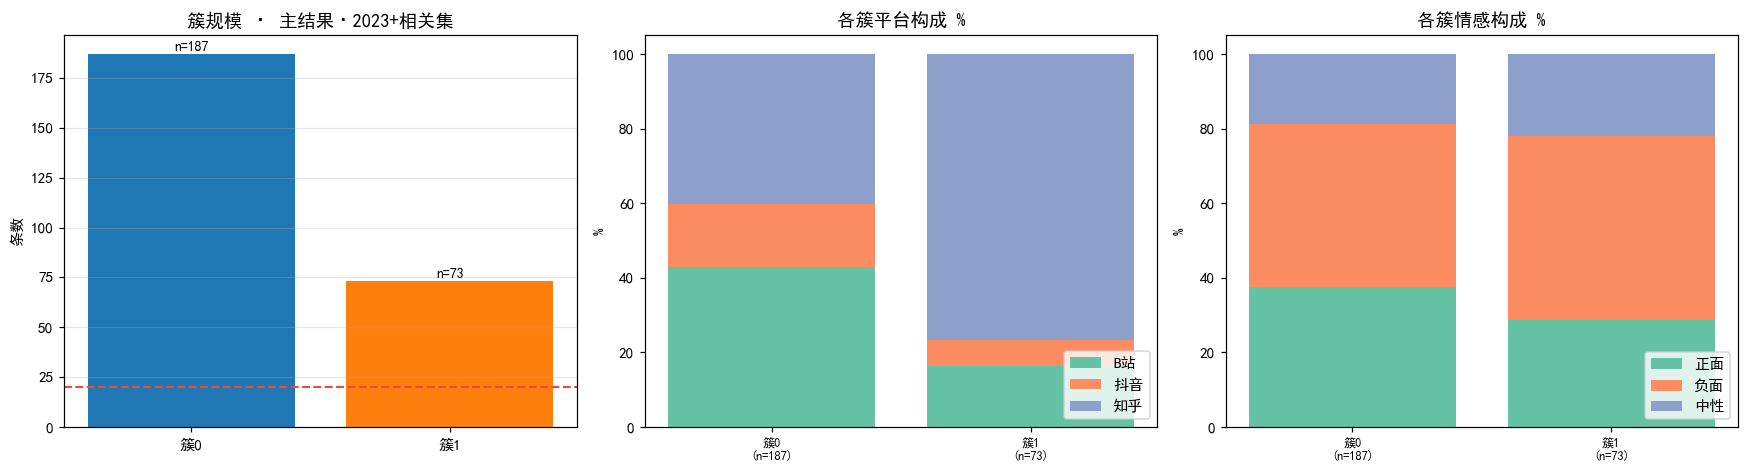

=== 主结果·2023+相关集 各簇 × 平台（条数）===
platform  B站  抖音   知乎   合计
cluster                   
0         80  32   75  187
1         12   5   56   73
合计        92  37  131  260

=== 主结果·2023+相关集 各簇 × 情感（条数）===
sentiment  中性  正面   负面   合计
cluster                    
0          35  70   82  187
1          16  21   36   73
合计         51  91  118  260



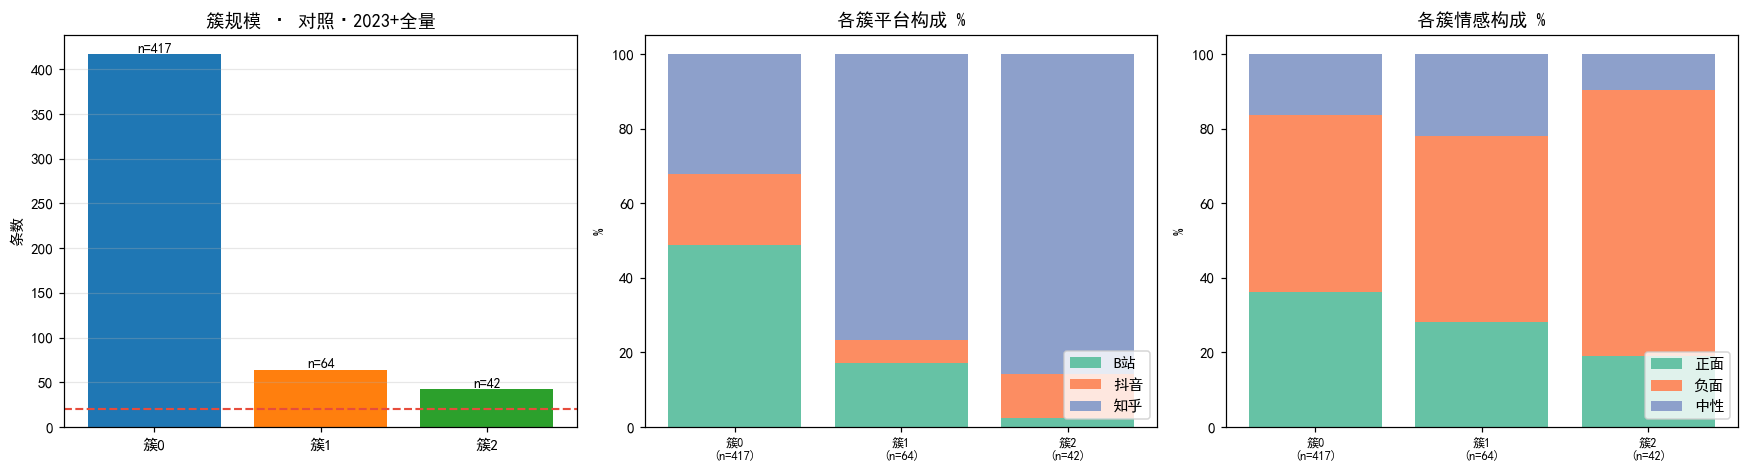

=== 对照·2023+全量 各簇 × 平台（条数）===
platform   B站  抖音   知乎   合计
cluster                    
0         203  80  134  417
1          11   4   49   64
2           1   5   36   42
合计        215  89  219  523

=== 对照·2023+全量 各簇 × 情感（条数）===
sentiment  中性   正面   负面   合计
cluster                     
0          68  151  198  417
1          14   18   32   64
2           4    8   30   42
合计         86  177  260  523



In [9]:
for key, r in results.items():
    sub, k = r['sub'], r['k']
    sizes = sub['cluster'].value_counts().sort_index()
    labels = [f'簇{c}\n(n={sizes[c]})' for c in range(k)]

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

    # 簇规模
    bars = ax[0].bar(range(k), sizes.values, color=plt.get_cmap('tab10')(range(k)))
    ax[0].axhline(MIN_CLUSTER, color='#E74C3C', ls='--', lw=1.4)
    for b in bars:
        ax[0].text(b.get_x()+b.get_width()/2, b.get_height()+1.5, f'n={int(b.get_height())}',
                   ha='center', fontproperties=font, fontsize=9)
    ax[0].set_xticks(range(k)); ax[0].set_xticklabels([f'簇{c}' for c in range(k)],
                                                     fontproperties=font)
    ax[0].set_title(f"簇规模 · {DATASETS[key]['name']}", fontproperties=font, fontsize=12)
    ax[0].set_ylabel('条数', fontproperties=font); ax[0].grid(alpha=.3, axis='y')

    # 平台构成
    ctp = pd.crosstab(sub['cluster'], sub['platform'], normalize='index') * 100
    bottom = np.zeros(k)
    for i, plat in enumerate(ctp.columns):
        ax[1].bar(range(k), ctp[plat], bottom=bottom, label=plat,
                  color=plt.get_cmap('Set2')(i))
        bottom += ctp[plat].values
    ax[1].set_xticks(range(k)); ax[1].set_xticklabels(labels, fontproperties=font, fontsize=8)
    ax[1].set_title('各簇平台构成 %', fontproperties=font, fontsize=12)
    ax[1].legend(prop=font, fontsize=8, loc='lower right'); ax[1].set_ylabel('%',
                                                                fontproperties=font)

    # 情感构成
    COL = {'正面': '#66c2a5', '负面': '#fc8d62', '中性': '#8da0cb'}
    cts = pd.crosstab(sub['cluster'], sub['sentiment'], normalize='index') * 100
    cts = cts.reindex(columns=['正面', '负面', '中性']).fillna(0)
    bottom = np.zeros(k)
    for s_ in ['正面', '负面', '中性']:
        ax[2].bar(range(k), cts[s_], bottom=bottom, label=s_, color=COL[s_])
        bottom += cts[s_].values
    ax[2].set_xticks(range(k)); ax[2].set_xticklabels(labels, fontproperties=font, fontsize=8)
    ax[2].set_title('各簇情感构成 %', fontproperties=font, fontsize=12)
    ax[2].legend(prop=font, fontsize=8, loc='lower right'); ax[2].set_ylabel('%',
                                                                fontproperties=font)

    plt.tight_layout()
    plt.savefig(FIG / f'03_cluster_profile_{key}.png', bbox_inches='tight')
    plt.show()

    print(f"=== {DATASETS[key]['name']} 各簇 × 平台（条数）===")
    print(pd.crosstab(sub['cluster'], sub['platform'], margins=True,
                      margins_name='合计').to_string())
    print()
    print(f"=== {DATASETS[key]['name']} 各簇 × 情感（条数）===")
    print(pd.crosstab(sub['cluster'], sub['sentiment'], margins=True,
                      margins_name='合计').to_string())
    print()

## 9. 落盘

In [10]:
for key, r in results.items():
    p = PROC / f'clusters_{key}.csv'
    cols = ['row_id', 'platform', 'keyword', 'created_at', 'year', 'on_topic',
            'content_clean', 'tokens', 'n_tokens', 'like_count',
            'p_pos', 'sentiment', 'topics', 'cluster', 'sil']
    r['sub'][[c for c in cols if c in r['sub'].columns]] \
        .to_csv(p, index=False, encoding='utf-8-sig')
    print('已写出 :', p.name, '|', len(r['sub']), '条 | K =', r['k'],
          '|', round(p.stat().st_size/1024, 1), 'KB')

print()
print('图表 :')
for f in sorted(FIG.glob('03_*.png')):
    print('  -', f.name, round(f.stat().st_size / 1024), 'KB')

print()
print('=== 最终交付摘要 ===')
summ = []
for key, v in DATASETS.items():
    k = CHOSEN[key]
    row = {'数据集': v['name'], 'n': int(v['mask'].sum()), '选定K': k}
    if key in stab_summary:
        row['平均ARI(n_init=10)'] = stab_summary[key]['mean_ARI']
        row['平均ARI(n_init=1)']  = stab_summary[key].get('mean_ARI_ninit1')
        row['稳定性判定'] = stab_summary[key]['判定']
    summ.append(row)
print(pd.DataFrame(summ).to_string(index=False))

已写出 : clusters_primary.csv | 260 条 | K = 2 | 89.8 KB
已写出 : clusters_control.csv | 523 条 | K = 3 | 155.4 KB

图表 :
  - 03_cluster_profile_control.png 36 KB
  - 03_cluster_profile_primary.png 34 KB
  - 03_elbow.png 56 KB
  - 03_pca_scatter.png 87 KB
  - 03_platform_n.png 34 KB
  - 03_silhouette_minsize.png 94 KB

=== 最终交付摘要 ===
         数据集   n  选定K  平均ARI(n_init=10)  平均ARI(n_init=1) 稳定性判定
主结果·2023+相关集 260    2            0.9681           0.0392    稳定
  对照·2023+全量 523    3            0.5721           0.3625    中等
